In [ ]:
# Machine Learning Pipeline

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df=pd.read_csv("improved_accident_data.csv")

In [14]:
df.head()

,Speed,Traffic_Volume,Driver_Alcohol,Weather,Time_of_Day,Road_Type,Accident_Risk,Road_Condition,Severity
0,79.760911,50.452617,0.0,1,1,2,73.772120,1,0
1,66.360916,82.190413,0.0,1,2,1,83.482605,1,0
2,74.074257,22.229149,0.0,0,0,1,43.615109,0,1
3,45.361901,75.056853,1.0,2,1,2,84.816125,1,0
4,63.904828,47.169485,1.0,0,2,1,92.203479,0,0


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [17]:
from sklearn.linear_model import LogisticRegression

# Prepare features and target
X = df.drop('Severity', axis=1)     #Features
y = df['Severity']   # Target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)

# Scaling (for LR & SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)

y_pred_lr = logreg.predict(X_test_scaled)



-- Logistic Regression --
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       148
           1       0.94      0.97      0.96       247
           2       0.95      0.93      0.94       205

    accuracy                           0.96       600
   macro avg       0.97      0.96      0.96       600
weighted avg       0.96      0.96      0.96       600

Accuracy: 0.9616666666666667
F1 Score: 0.9616632142618267


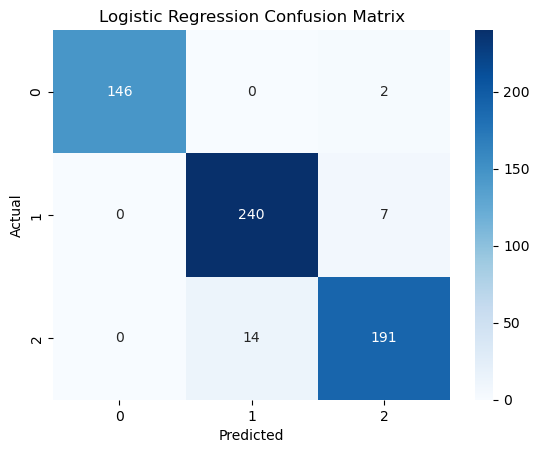

In [18]:
print("\n-- Logistic Regression --")
print(classification_report(y_test, y_pred_lr))
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr, average='weighted'))

cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


-- SVM --
              precision    recall  f1-score   support

           0       0.97      0.95      0.96       148
           1       0.95      0.97      0.96       247
           2       0.93      0.92      0.92       205

    accuracy                           0.95       600
   macro avg       0.95      0.95      0.95       600
weighted avg       0.95      0.95      0.95       600

Accuracy: 0.9483333333333334
F1 Score: 0.9483101833024218


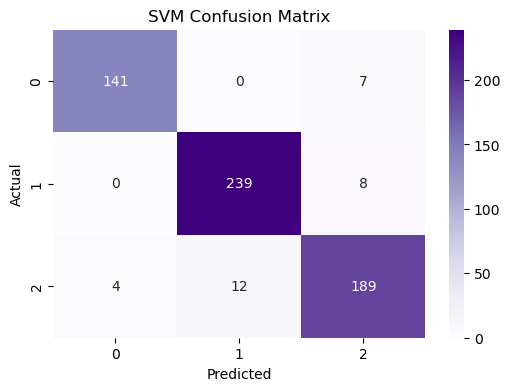

In [19]:
from sklearn.svm import SVC

#SVM

svm_model = SVC(kernel='rbf', C=10, gamma=0.1, probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)

print("\n-- SVM --")
print(classification_report(y_test, y_pred_svm))
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("F1 Score:", f1_score(y_test, y_pred_svm, average='weighted'))

cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(6,4))
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Purples")
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


-- KNN --
              precision    recall  f1-score   support

           0       0.81      0.72      0.76       148
           1       0.86      0.88      0.87       247
           2       0.68      0.71      0.69       205

    accuracy                           0.78       600
   macro avg       0.78      0.77      0.78       600
weighted avg       0.78      0.78      0.78       600

Accuracy: 0.7833333333333333
F1 Score: 0.7832563650968322


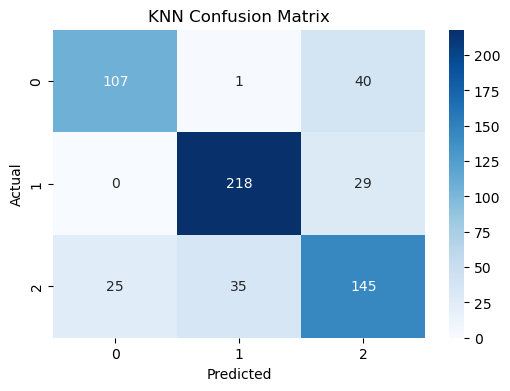

In [20]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# --------- KNN ---------
# Create KNN classifier
knn_model = KNeighborsClassifier(n_neighbors=5)  # you can change k

# Train the model
knn_model.fit(X_train_scaled, y_train)

# Predict on test set
y_pred_knn = knn_model.predict(X_test_scaled)

# Evaluation
print("\n-- KNN --")
print(classification_report(y_test, y_pred_knn))
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("F1 Score:", f1_score(y_test, y_pred_knn, average='weighted'))

# Confusion Matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(6,4))
sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Blues")
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


=== Random Forest ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       148
           1       1.00      1.00      1.00       247
           2       1.00      1.00      1.00       205

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600

Accuracy: 1.0
F1 Score: 1.0


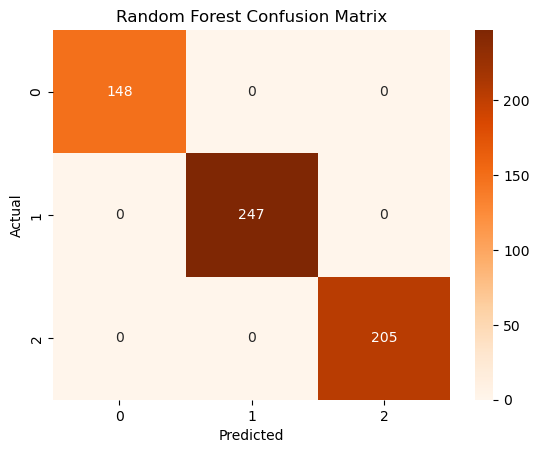

In [21]:
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
# Random Forest
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    random_state=42,
    class_weight='balanced'
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("\n=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf, average='weighted'))

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Oranges")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

